# Marker peaks and differential accessibility

Once cells are grouped (by cluster or annotated cell type), the natural question is **which
regulatory regions define each group**. `ov.epi.tl.find_marker_features` runs an ArchR-style
test — a Wilcoxon test of each peak against a bias-matched background of the other cells — to rank
the marker peaks of every group.

We use the annotated **10x PBMC 10k multiome** ATAC peak matrix (`cell_type` already provided) so
the marker peaks can be read against known cell types:

1. rank marker peaks per cell type (`ov.epi.tl.find_marker_features`)
2. inspect the top markers and annotate them to their nearest gene
3. visualise one cell type's differential accessibility as a volcano plot
4. summarise top marker accessibility across cell types as a heatmap

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import omicverse as ov
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1


## 1 · Load the annotated ATAC peak matrix

In [2]:
atac, _ = ov.epi.datasets.pbmc10k_multiome()
print('ATAC peak matrix:', atac.shape)
atac.obs['cell_type'].value_counts()

ATAC peak matrix: (9631, 107194)


cell_type
CD14 Mono         2554
CD4 Naive         1382
CD8 Naive         1354
CD4 TCM           1113
CD16 Mono          442
NK                 403
CD8 TEM_1          322
CD8 TEM_2          315
Intermediate B     300
Memory B           298
CD4 TEM            286
cDC                180
Treg               157
gdT                143
MAIT               130
Naive B            125
pDC                 98
HSPC                17
Plasma              12
Name: count, dtype: int64

## 2 · Marker peaks per cell type

`find_marker_features` returns a tidy table — one row per (group, peak) — with effect size
(`log2_fc`), detection fractions, and significance (`fdr`).

In [3]:
markers = ov.epi.tl.find_marker_features(atac, group_by='cell_type')
print('marker table:', markers.shape)
markers.head()

  └─ [find_marker_features] group='CD4 Naive' | fg=1,382 cells | bg=1,382 cells (matched=no)


  └─ [find_marker_features] group='CD4 TCM' | fg=1,113 cells | bg=1,113 cells (matched=no)


  └─ [find_marker_features] group='CD4 TEM' | fg=286 cells | bg=286 cells (matched=no)


  └─ [find_marker_features] group='CD8 Naive' | fg=1,354 cells | bg=1,354 cells (matched=no)


  └─ [find_marker_features] group='CD8 TEM_1' | fg=322 cells | bg=322 cells (matched=no)


...

  └─ [find_marker_features] group='cDC' | fg=180 cells | bg=180 cells (matched=no)


  └─ [find_marker_features] group='gdT' | fg=143 cells | bg=143 cells (matched=no)


  └─ [find_marker_features] group='pDC' | fg=98 cells | bg=98 cells (matched=no)


marker table: (2036686, 13)


,group,feature,mean_fg,mean_bg,pct_fg,pct_bg,log2_fc,U,z,p_value,fdr,n_fg,n_bg
0,CD4 Naive,chr1:816881-817647,0.017366,0.104197,0.009407,0.047033,-2.584893,918951.5,-5.984385,2.172087e-09,1.390224e-08,1382,1382
1,CD4 Naive,chr1:819912-823500,0.103473,0.151954,0.047757,0.068017,-0.554370,935616.5,-2.279238,2.265292e-02,3.937566e-02,1382,1382
2,CD4 Naive,chr1:825827-825889,0.002171,0.000000,0.002171,0.000000,11.084654,957035.0,1.732678,8.315291e-02,1.252705e-01,1382,1382
3,CD4 Naive,chr1:826612-827979,0.397250,0.463097,0.184515,0.205499,-0.221265,933151.0,-1.511729,1.306028e-01,1.867460e-01,1382,1382
4,CD4 Naive,chr1:841243-843059,0.117945,0.035456,0.064399,0.019537,1.733990,997784.5,5.876457,4.191396e-09,2.571794e-08,1382,1382


### Top markers for a few cell types

Filtering to significant, up-accessible peaks (`fdr < 0.05`, `log2_fc > 0`) and taking the top by
effect size gives each cell type's most specific regulatory regions.

In [4]:
sig = markers[(markers['fdr'] < 0.05) & (markers['log2_fc'] > 0)]
top = (sig.sort_values('log2_fc', ascending=False)
          .groupby('group').head(5))
for ct in ['CD14 Mono', 'Naive B', 'NK']:
    if ct in set(top['group']):
        print(f'\n=== {ct} top marker peaks ===')
        print(top[top['group'] == ct][['feature', 'log2_fc', 'pct_fg', 'pct_bg', 'fdr']]
              .to_string(index=False))


=== CD14 Mono top marker peaks ===
                  feature   log2_fc  pct_fg  pct_bg          fdr
      chr18:400354-400952 17.587843  0.0950     0.0 4.203895e-44
 chr2:126831558-126832185 17.074320  0.0635     0.0 1.981806e-29
 chr9:124143849-124144330 16.884659  0.0650     0.0 4.058194e-30
chr10:116465495-116465971 16.686897  0.0600     0.0 7.918512e-28
  chr18:25299007-25299800 16.587851  0.0485     0.0 1.317443e-22

=== Naive B top marker peaks ===
                 feature   log2_fc  pct_fg  pct_bg          fdr
  GL000205.2:67888-69629 20.919981   0.552     0.0 3.561571e-18
 chr11:60455290-60456088 20.652287   0.544     0.0 6.521199e-18
  chr5:78727641-78728723 20.595142   0.504     0.0 3.093037e-16
 chr18:76980792-76981819 19.896523   0.368     0.0 3.864268e-11
chr7:139714137-139715063 19.747145   0.320     0.0 1.753880e-09

=== NK top marker peaks ===
                 feature   log2_fc   pct_fg  pct_bg          fdr
chr1:162411943-162412452 19.116138 0.240695     0.0 4.920916e-

## 3 · Annotate top marker peaks to their nearest gene

A marker peak is most interpretable next to a gene name. We assign each top peak to the nearest
gene TSS using the Gencode annotation.

In [5]:
import pyranges as pr
g = pr.read_gff3(str(ov.epi.data.hg38.annotation)).df
gene_ann = g[g.Feature == 'gene'][['gene_name', 'Chromosome', 'Start', 'End', 'Strand']].copy()
gene_ann.columns = ['gene_name', 'chrom', 'start', 'end', 'strand']
gene_ann['tss'] = np.where(gene_ann['strand'] == '+', gene_ann['start'], gene_ann['end'])

def nearest_gene(peak):
    chrom, rng = peak.split(':'); s, e = rng.split('-')
    center = (int(s) + int(e)) // 2
    sub = gene_ann[gene_ann['chrom'] == chrom]
    if sub.empty:
        return ('NA', np.nan)
    i = (sub['tss'] - center).abs().values.argmin()
    row = sub.iloc[i]
    return (row['gene_name'], int(abs(row['tss'] - center)))

top = top.copy()
top[['nearest_gene', 'dist_to_tss']] = [nearest_gene(p) for p in top['feature']]
top[top['group'].isin(['CD14 Mono', 'Naive B', 'NK'])][
    ['group', 'feature', 'log2_fc', 'nearest_gene', 'dist_to_tss']].head(15)

,group,feature,log2_fc,nearest_gene,dist_to_tss
1500690,Naive B,GL000205.2:67888-69629,20.919981,NA,NaN
1410865,Naive B,chr11:60455290-60456088,20.652287,MS4A1,156.0
1473922,Naive B,chr5:78727641-78728723,20.595142,ENSG00000254170,12100.0
1440859,Naive B,chr18:76980792-76981819,19.896523,ENSG00000266844,6616.0
1488361,Naive B,chr7:139714137-139715063,19.747145,TBXAS1,62450.0
1293369,NK,chr1:162411943-162412452,19.116138,SH2D1B,59.0
1298310,NK,chr10:34348914-34349332,18.956415,ELOBP4,139755.0
1320577,NK,chr15:69499406-69499933,18.823830,DRAIC,36749.0
1321922,NK,chr15:98952272-98953616,18.816095,PGPEP1L,54848.0
1293370,NK,chr1:162413846-162414255,18.616787,SH2D1B,1912.0


## 4 · Volcano plot for one cell type

Plotting effect size against significance for all peaks tested in a single cell type (here
**CD14 monocytes**) gives the familiar volcano view of differential accessibility.

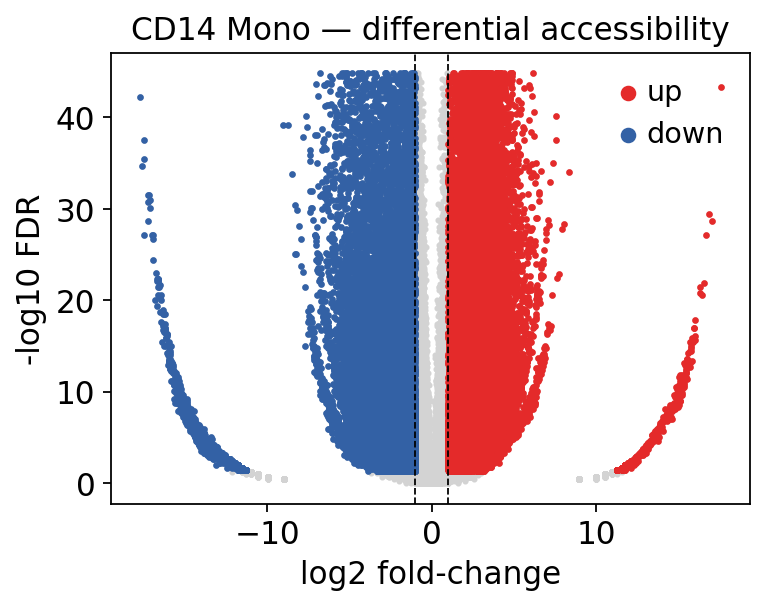

In [6]:
ct = 'CD14 Mono'
sub = markers[markers['group'] == ct].copy()
sub['neglog10_fdr'] = -np.log10(sub['fdr'].clip(lower=1e-300))
up = (sub['fdr'] < 0.05) & (sub['log2_fc'] > 1)
dn = (sub['fdr'] < 0.05) & (sub['log2_fc'] < -1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(sub['log2_fc'], sub['neglog10_fdr'], s=3, c='lightgray')
ax.scatter(sub.loc[up, 'log2_fc'], sub.loc[up, 'neglog10_fdr'], s=4, c='#E42A2A', label='up')
ax.scatter(sub.loc[dn, 'log2_fc'], sub.loc[dn, 'neglog10_fdr'], s=4, c='#3361A5', label='down')
ax.axvline(1, ls='--', lw=.8, c='k'); ax.axvline(-1, ls='--', lw=.8, c='k')
ax.set_xlabel('log2 fold-change'); ax.set_ylabel('-log10 FDR')
ax.set_title(f'{ct} — differential accessibility'); ax.legend(markerscale=3, frameon=False)
plt.tight_layout(); plt.show()

## 5 · Marker accessibility heatmap

Taking the top markers across cell types and plotting their mean (z-scored) accessibility per
cell type produces a block-diagonal heatmap — each set of marker peaks is specific to its
cell type.

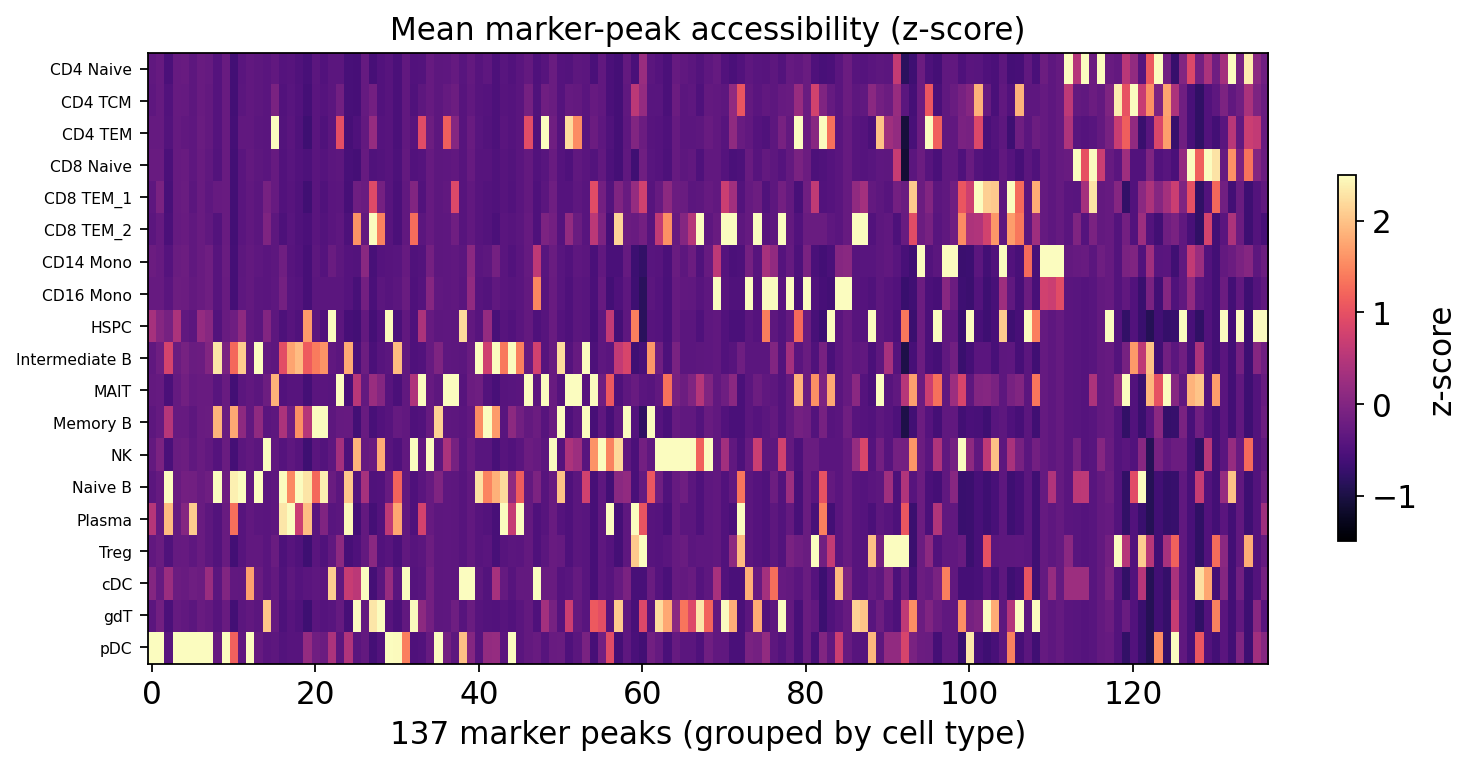

In [7]:
from scipy.sparse import issparse

# top 8 markers per cell type
topn = (sig.sort_values('log2_fc', ascending=False).groupby('group').head(8))
peaks = topn['feature'].unique().tolist()
peak_idx = [atac.var_names.get_loc(p) for p in peaks]

X = atac.X[:, peak_idx]
X = X.toarray() if issparse(X) else np.asarray(X)
X = np.log1p(X)
df = pd.DataFrame(X, columns=peaks)
df['cell_type'] = atac.obs['cell_type'].values
mean_acc = df.groupby('cell_type').mean()
z = (mean_acc - mean_acc.mean(0)) / (mean_acc.std(0) + 1e-9)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(z.values, aspect='auto', cmap='magma', vmin=-1.5, vmax=2.5)
ax.set_yticks(range(z.shape[0])); ax.set_yticklabels(z.index, fontsize=7)
ax.set_xlabel(f'{len(peaks)} marker peaks (grouped by cell type)')
ax.set_title('Mean marker-peak accessibility (z-score)')
plt.colorbar(im, ax=ax, label='z-score', shrink=0.6)
plt.tight_layout(); plt.show()

## Summary

| stage | function |
|---|---|
| marker peaks per group | `ov.epi.tl.find_marker_features` |
| peak → nearest gene | Gencode annotation (`ov.epi.data.hg38.annotation`) |
| differential accessibility | volcano of `log2_fc` vs `fdr` |

`find_marker_features` works equally on a peak matrix, a gene-score matrix or gene expression — so
the same call ranks marker peaks, marker gene-activities, or marker genes. For two-group designs
with replicates, `ov.epi.tl.differential_peaks` offers a pseudobulk pyDESeq2 test.